In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import re

In [2]:
df = pd.read_excel("balanced_edufeed_dataset.xlsx")
df = df[['comments', 'sentiment_label']].dropna()
df['comments'] = df['comments'].astype(str)

In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\b[A-Z][a-z]+\b', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_comments'] = df['comments'].apply(clean_text)

In [4]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment_label'])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_comments'],
    df['label'],
    test_size=0.2,
    random_state=42
)

In [6]:
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=15000,
    output_sequence_length=120
)

vectorizer.adapt(X_train[:6000])  # important for speed
X_train_vec = vectorizer(X_train)
X_test_vec = vectorizer(X_test)

In [7]:
model = keras.Sequential([
    keras.layers.Embedding(15000, 128),
    keras.layers.Bidirectional(keras.layers.LSTM(64)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(len(le.classes_), activation='softmax')
])

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [10]:
history = model.fit(
    X_train_vec,
    y_train,
    epochs=15,
    validation_split=0.2,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.6403 - loss: 0.7962 - val_accuracy: 0.7383 - val_loss: 0.6256
Epoch 2/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7877 - loss: 0.5451 - val_accuracy: 0.7867 - val_loss: 0.5442
Epoch 3/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8442 - loss: 0.4174 - val_accuracy: 0.8084 - val_loss: 0.5023
Epoch 4/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8730 - loss: 0.3371 - val_accuracy: 0.8202 - val_loss: 0.4956
Epoch 5/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8936 - loss: 0.2809 - val_accuracy: 0.8267 - val_loss: 0.4777
Epoch 6/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9011 - loss: 0.2550 - val_accuracy: 0.8207 - val_loss: 0.6029
Epoch 7/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9181 - loss: 0.2117 - val_accuracy: 0.8410 - val_loss: 0.5444
Epoch 8/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9274 - loss: 0.1883 - val_acc

In [11]:
y_pred = np.argmax(model.predict(X_test_vec), axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
              precision    recall  f1-score   support

    Negative       0.80      0.89      0.84      2289
     Neutral       0.82      0.84      0.83      2406
    Positive       0.86      0.75      0.80      2389

    accuracy                           0.82      7084
   macro avg       0.83      0.82      0.82      7084
weighted avg       0.83      0.82      0.82      7084



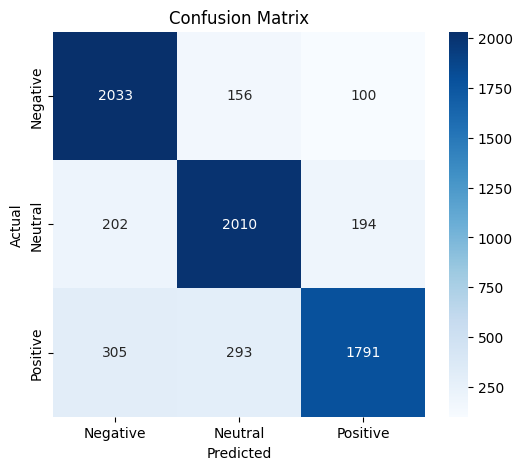

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [13]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8235460191981931
